<a href="https://colab.research.google.com/github/vidhanj2107-bot/Diabetes-Prediction-Model-mini-project-/blob/main/Diabetes(83_78_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install -q lightgbm boruta imbalanced-learn shap

# Code for explanation of 'paper 5 features' and Boruta features
# 'Paper 5 Features' are explicitly defined as:
# Glucose, SkinThickness, BMI, DiabetesPedigreeFunction, Age
paper_features_explanation = [
    "Glucose",
    "SkinThickness",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

# Boruta selected features are dynamically determined by the BorutaPy algorithm
# In this notebook, Boruta selected:
# boruta_features_explanation = ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']

print(f"'Paper 5 Features' are: {paper_features_explanation}")
print(f"Boruta selected features are: {boruta_features}")
print("As you can see, they are not identical. The 'paper 5 features' are a fixed set, likely from a prior study, while Boruta's selection is data-driven from this dataset.")


'Paper 5 Features' are: ['Glucose', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Boruta selected features are: ['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']
As you can see, they are not identical. The 'paper 5 features' are a fixed set, likely from a prior study, while Boruta's selection is data-driven from this dataset.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import RandomOverSampler
from boruta import BorutaPy
from lightgbm import LGBMClassifier

sns.set(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

In [3]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, header=None, names=columns)

print("Dataset shape:", df.shape)
display(df.head())
print("\nClass distribution:")
print(df["Outcome"].value_counts())

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [4]:
print(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


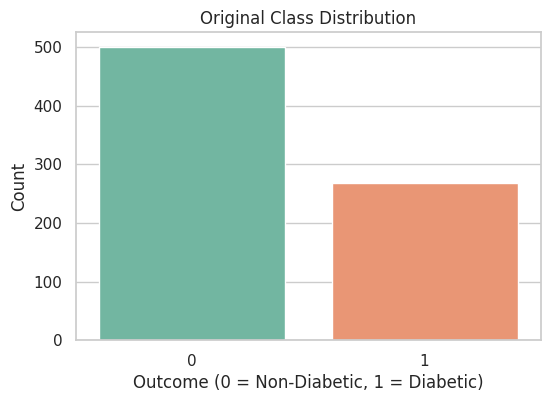

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Outcome"], palette="Set2")
plt.title("Original Class Distribution")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Count")
plt.show()

print(df["Outcome"].value_counts(normalize=True) * 100)

In [6]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_as_missing:
    print(f"{col}: {(df[col] == 0).sum()} zeros")

Glucose: 5 zeros
BloodPressure: 35 zeros
SkinThickness: 227 zeros
Insulin: 374 zeros
BMI: 11 zeros


In [7]:
df_clean = df.copy()

df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

imputer = SimpleImputer(strategy="mean")
df_clean[zero_as_missing] = imputer.fit_transform(df_clean[zero_as_missing])

print("Missing values after imputation:")
print(df_clean.isnull().sum())
display(df_clean.head())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1


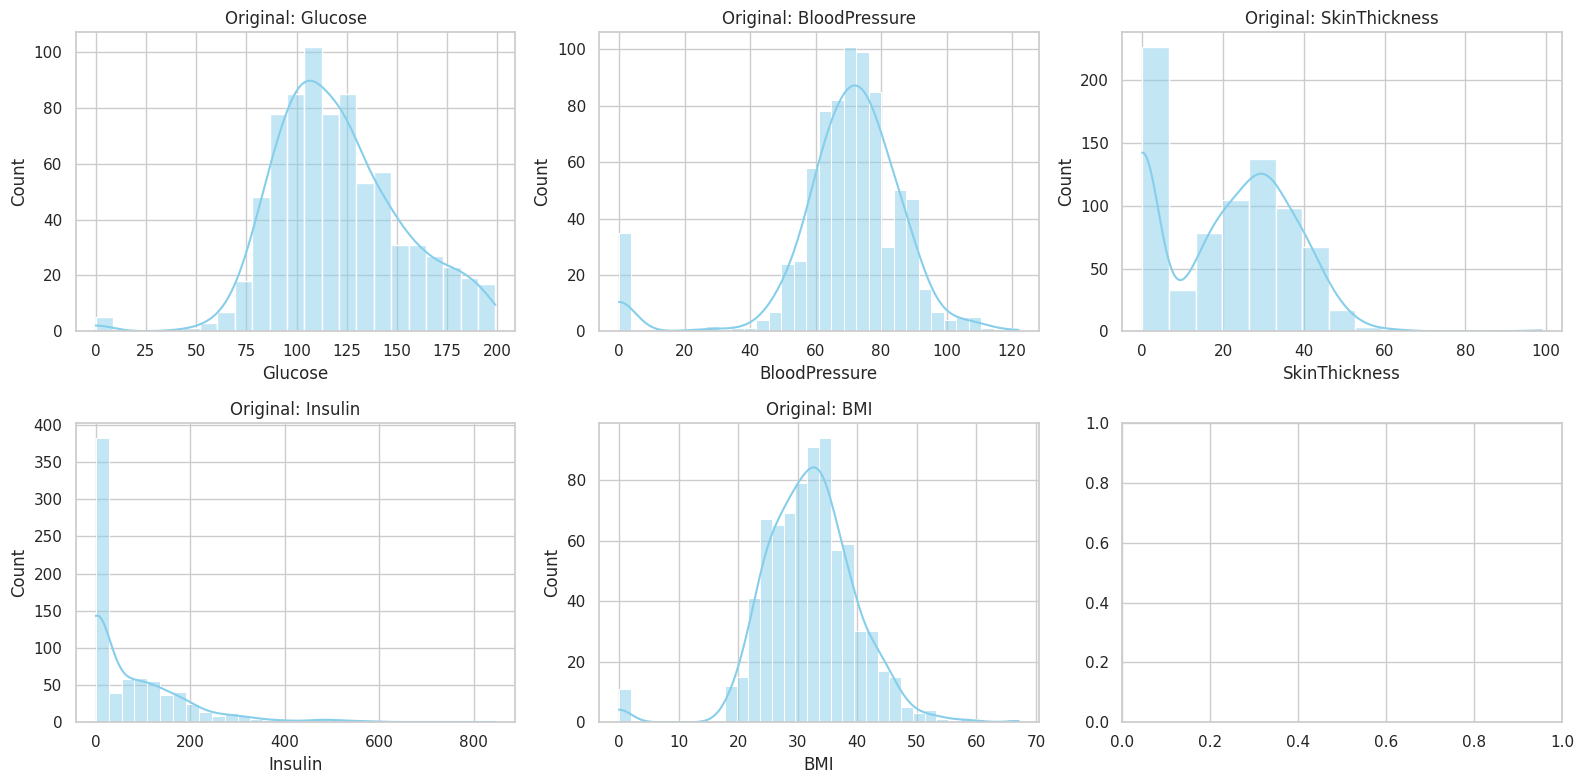

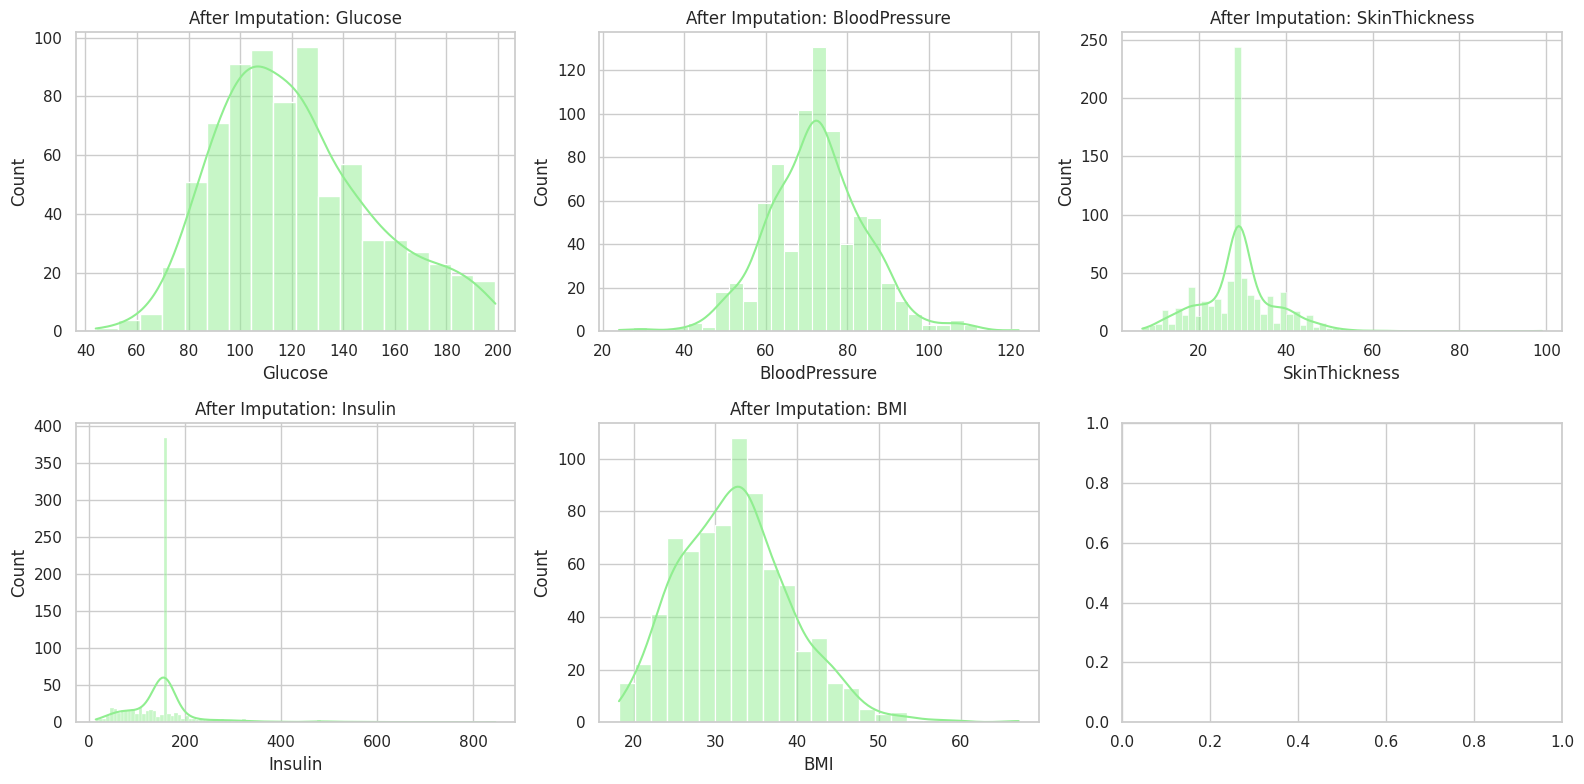

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(zero_as_missing):
    sns.histplot(df[col], kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Original: {col}")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(zero_as_missing):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color="lightgreen")
    axes[i].set_title(f"After Imputation: {col}")

plt.tight_layout()
plt.show()

In [9]:
def remove_outliers_iqr(dataframe, feature_columns):
    df_out = dataframe.copy()
    mask = pd.Series(True, index=df_out.index)

    for col in feature_columns:
        q1 = df_out[col].quantile(0.25)
        q3 = df_out[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask &= df_out[col].between(lower, upper)

    return df_out[mask]

feature_cols = [c for c in df_clean.columns if c != "Outcome"]

print("Before outlier removal:", df_clean.shape)
df_iqr = remove_outliers_iqr(df_clean, feature_cols)
print("After outlier removal :", df_iqr.shape)

Before outlier removal: (768, 9)
After outlier removal : (515, 9)


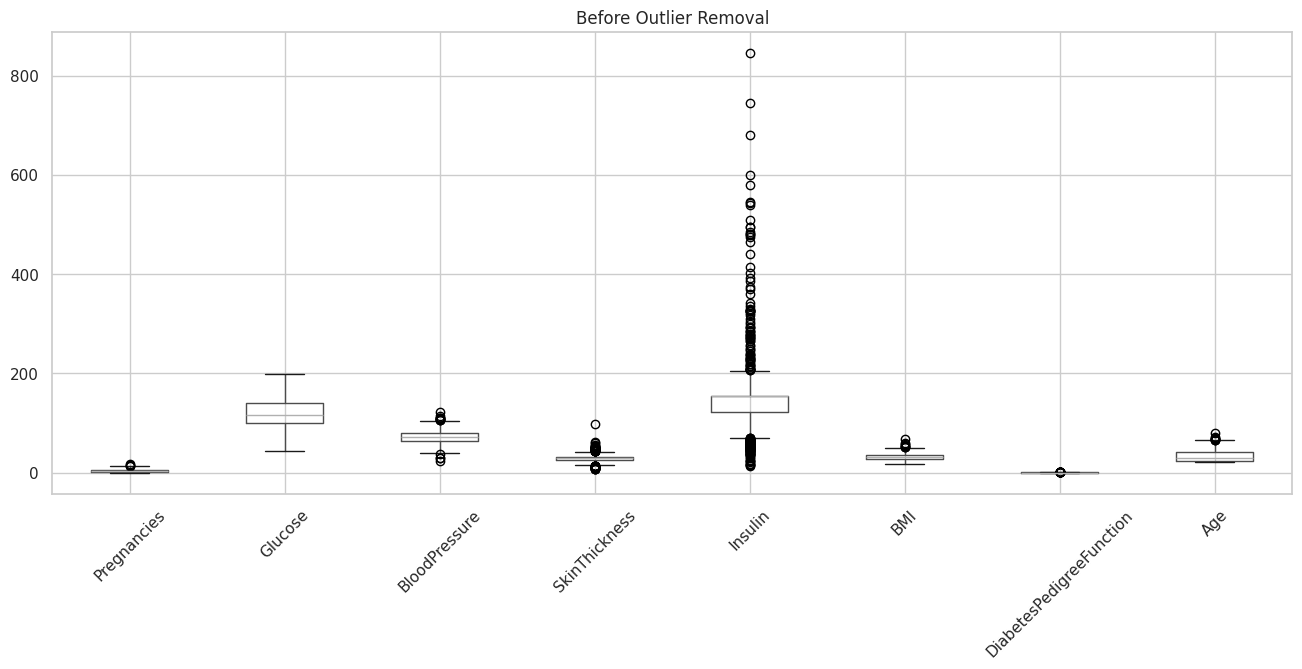

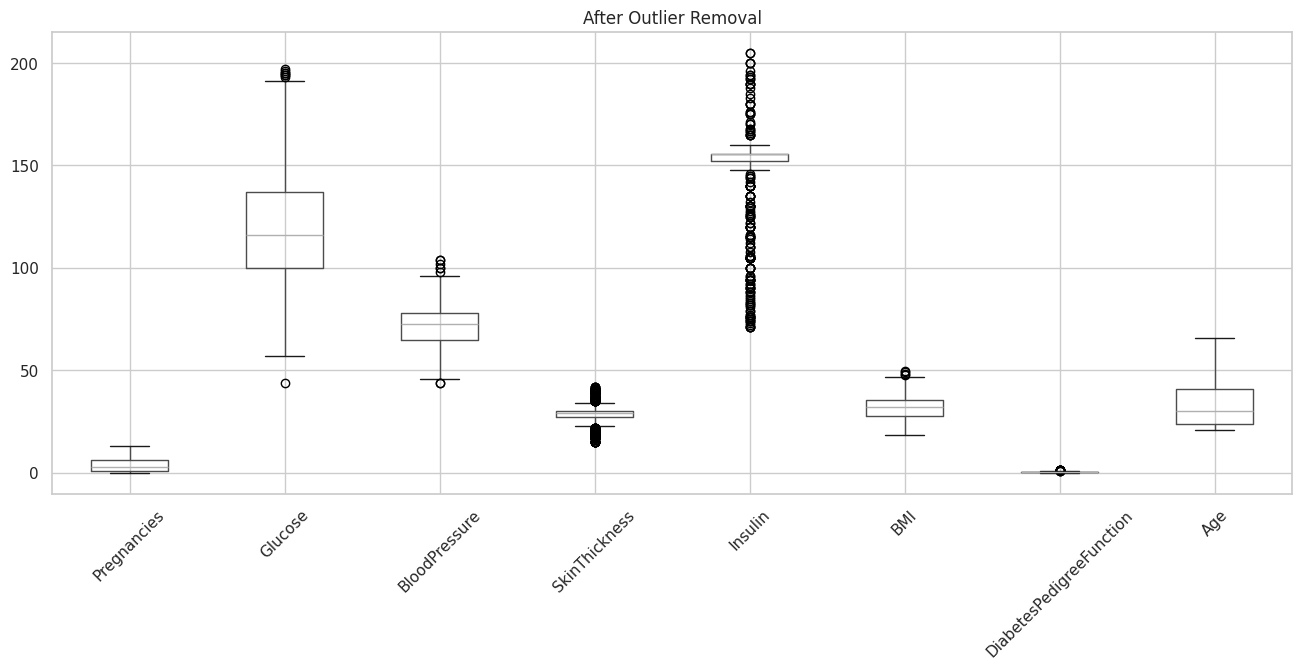

In [10]:
plt.figure(figsize=(16, 6))
df_clean[feature_cols].boxplot(rot=45)
plt.title("Before Outlier Removal")
plt.show()

plt.figure(figsize=(16, 6))
df_iqr[feature_cols].boxplot(rot=45)
plt.title("After Outlier Removal")
plt.show()

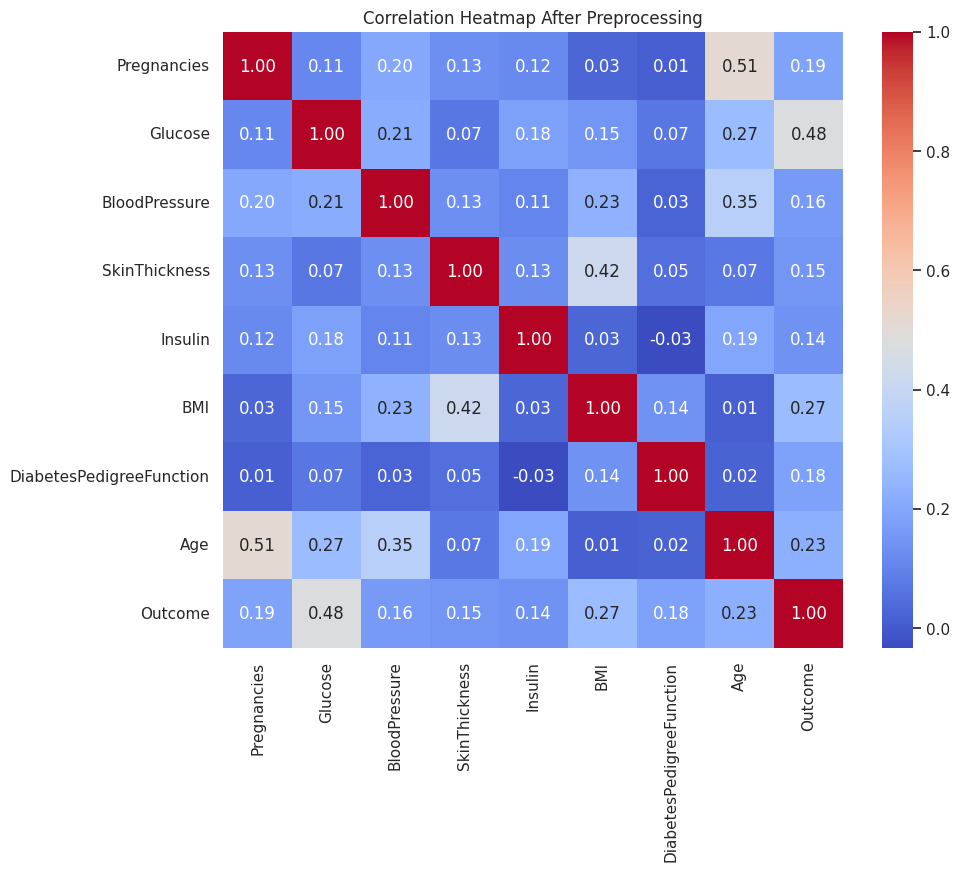

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_iqr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap After Preprocessing")
plt.show()

In [12]:
X = df_iqr.drop(columns=["Outcome"])
y = df_iqr["Outcome"]

print("Feature shape:", X.shape)
print("Target shape :", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (515, 8)
Target shape : (515,)

Target distribution:
Outcome
0    336
1    179
Name: count, dtype: int64


In [13]:
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_resampled, y_resampled = ros.fit_resample(X, y)

X_resampled = pd.DataFrame(X_resampled, columns=X.columns)
y_resampled = pd.Series(y_resampled, name="Outcome")

print("Before oversampling:")
print(y.value_counts())

print("\nAfter oversampling:")
print(y_resampled.value_counts())

Before oversampling:
Outcome
0    336
1    179
Name: count, dtype: int64

After oversampling:
Outcome
1    336
0    336
Name: count, dtype: int64


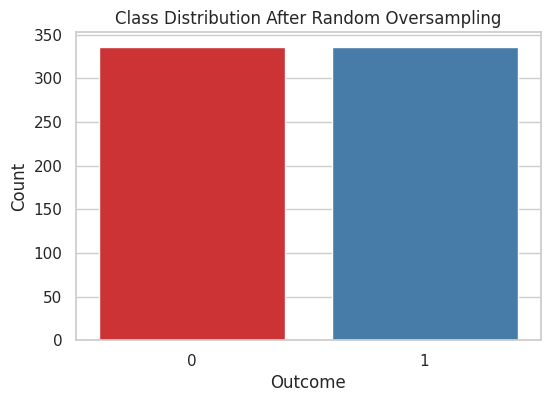

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_resampled, palette="Set1")
plt.title("Class Distribution After Random Oversampling")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.20,
    stratify=y_resampled,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (537, 8)
X_test : (135, 8)
y_train: (537,)
y_test : (135,)


In [16]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1
)

boruta_selector = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    max_iter=150,
    random_state=RANDOM_STATE
)

boruta_selector.fit(X_train.values, y_train.values)

boruta_features = X_train.columns[boruta_selector.support_].tolist()
print("Boruta selected features:")
print(boruta_features)

paper_features = [
    "Glucose",
    "SkinThickness",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]
print("\nPaper-reported features:")
print(paper_features)

if len(boruta_features) == 0:
    boruta_features = paper_features

Boruta selected features:
['Glucose', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Paper-reported features:
['Glucose', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,Feature,Selected,Tentative,Ranking
1,Glucose,True,False,1
7,Age,True,False,1
6,DiabetesPedigreeFunction,True,False,1
5,BMI,True,False,1
2,BloodPressure,False,False,2
3,SkinThickness,False,False,3
0,Pregnancies,False,False,4
4,Insulin,False,False,5


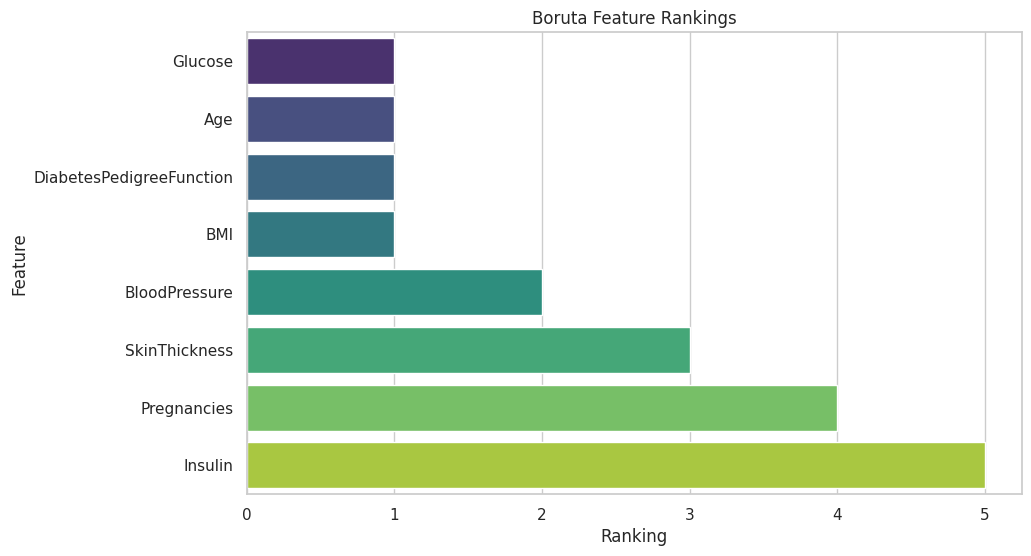

In [17]:
feature_ranks = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": boruta_selector.support_,
    "Tentative": boruta_selector.support_weak_,
    "Ranking": boruta_selector.ranking_
}).sort_values("Ranking")

display(feature_ranks)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_ranks, x="Ranking", y="Feature", palette="viridis")
plt.title("Boruta Feature Rankings")
plt.show()

In [18]:
def evaluate_model(model, X_train, X_test, y_train, y_test, label="Model"):
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": label,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "TrainTimeSec": train_time,
        "Predictions": y_pred,
        "Probabilities": y_prob
    }

In [19]:
param_grid = {
    "n_estimators": [50, 100, 150, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [-1, 3, 5, 7, 10],
    "num_leaves": [7, 15, 31, 63, 127],
    "min_child_samples": [5, 10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0]
}

all_params = list(ParameterGrid(param_grid))
print("Total combinations:", len(all_params))

random.shuffle(all_params)
search_params = all_params[:80]   # increase to 120 if Colab runtime is okay
print("Using combinations:", len(search_params))

Total combinations: 768000
Using combinations: 80


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune_lgbm(X_data, y_data, feature_set_name):
    best_score = -1
    best_params = None
    history = []

    print(f"\nStarting tuning for: {feature_set_name}")

    for i, params in enumerate(search_params, 1):
        model = LGBMClassifier(
            random_state=RANDOM_STATE,
            objective="binary",
            **params
        )

        scores = cross_val_score(model, X_data, y_data, cv=cv, scoring="accuracy")
        mean_score = scores.mean()

        history.append({
            "iteration": i,
            "cv_accuracy": mean_score,
            **params
        })

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

        if i % 10 == 0:
            print(f"Checked {i}/{len(search_params)} | Best CV Accuracy so far: {best_score:.4f}")

    history_df = pd.DataFrame(history)
    return best_params, best_score, history_df

In [35]:
best_params_paper, best_cv_paper, history_paper = tune_lgbm(
    X_resampled_paper,
    y_resampled,
    "Paper 5 Features"
)

print("\nBest CV accuracy (Paper 5 Features):", best_cv_paper)
print("Best params:", best_params_paper)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [36]:
best_params_boruta, best_cv_boruta, history_boruta = tune_lgbm(
    X_resampled_boruta,
    y_resampled,
    "Boruta Features"
)

print("\nBest CV accuracy (Boruta Features):", best_cv_boruta)
print("Best params:", best_params_boruta)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [37]:
best_params_all, best_cv_all, history_all = tune_lgbm(
    X_resampled,
    y_resampled,
    "All Features"
)

print("\nBest CV accuracy (All Features):", best_cv_all)
print("Best params:", best_params_all)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [40]:
print("===== FINAL RESULT BASED ON MY RUN =====")
print(f"Best CV Accuracy: {best_cv_all:.4f} ({best_cv_all*100:.2f}%)")
print("Best Parameters:")
print(best_params_all)

===== FINAL RESULT BASED ON MY RUN =====
Best CV Accuracy: 0.8378 (83.78%)
Best Parameters:
{'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_samples': 20, 'n_estimators': 500, 'num_leaves': 15, 'reg_alpha': 0.0, 'reg_lambda': 0.5, 'subsample': 0.9}


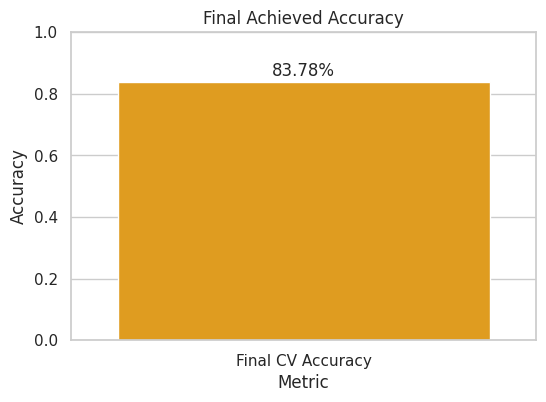

In [41]:
final_accuracy = best_cv_all  # your achieved result from screenshot

final_graph_df = pd.DataFrame({
    "Metric": ["Final CV Accuracy"],
    "Score": [final_accuracy]
})

plt.figure(figsize=(6,4))
sns.barplot(data=final_graph_df, x="Metric", y="Score", palette=["orange"])
plt.title("Final Achieved Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)

for i, row in final_graph_df.iterrows():
    plt.text(i, row["Score"] + 0.02, f"{row['Score']*100:.2f}%", ha="center", fontsize=12)

plt.show()

In [42]:
final_features = X_resampled.columns.tolist()

print("===== FEATURES USED IN FINAL MODEL =====")
print(f"Number of features used: {len(final_features)}")
print("Features:")
for feature in final_features:
    print("-", feature)

===== FEATURES USED IN FINAL MODEL =====
Number of features used: 8
Features:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
